# Supervised Learning for Journey Purpose Prediction
This notebook implements and evaluates two supervised learning models to predict a person's dominant journey purpose (Work vs. Education).

### 1. Setup & Data Loading

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_theme(style="whitegrid")

# Define paths
REPO_ROOT = Path('.').resolve().parent
DATA_FILE = REPO_ROOT / 'data' / 'processed_data' / 'master_processed.csv'

# Load data
if DATA_FILE.exists():
    df = pd.read_csv(DATA_FILE)
    print(f"Data loaded successfully from {DATA_FILE}")
    print(f"Shape: {df.shape}")
else:
    print(f"Error: {DATA_FILE} not found. Please run the preprocessing script first.")

Data loaded successfully from C:\Users\Adrian\Documents\Adrian\Melb_Uni\2025\sem2\data processing\vista_as2\data\processed_data\master_processed.csv
Shape: (8175, 80)


### 2. Data Preparation and Feature Engineering
 - Create the 'dominant_purpose' target variable from 'work_trips' and 'edu_trips' and select features for modeling. 
 - We need to handle categorical and numerical features separately.

In [44]:
# Create the target variable
def make_dominant_purpose(df):
    """Label by whichever trip count is higher."""
    out = df.copy()
    out['dominant_purpose'] = pd.NA
    out.loc[out['work_trips'] > out['edu_trips'], 'dominant_purpose'] = 'Work'
    out.loc[out['edu_trips'] > out['work_trips'], 'dominant_purpose'] = 'Education'
    return out.dropna(subset=['dominant_purpose'])

model_df = make_dominant_purpose(df)


# CONVERT 'age_decade' TO NUMERICAL
age_order = [
    '0->9', '10->19', '20->29', '30->39', '40->49', '50->59',
    '60->69', '70->79', '80->89', '90->99', '100+'
]
# Create a mapping from the string category to an integer
age_mapping = {category: i for i, category in enumerate(age_order)}
# Apply the mapping to convert the column to numerical
model_df['age_decade'] = model_df['age_decade'].map(age_mapping)



# Select Features (X) and Target (y)
features = [
    'carlicence', 'mainact', 'age_decade', 'employment_status', 'life_stage', 'personal_income', 'car_mobility', 'total_trips', 
    'peak_hour_ratio', 'avg_trip_distance', 'avg_trip_duration', 'household_income', 
    'vehicle_availability', 'is_city'
]
target = 'dominant_purpose'

X = model_df[features]
y = model_df[target]



# Identify categorical and numerical features for preprocessing in next section
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=np.number).columns


print(f"Target variable distribution:\n{y.value_counts(normalize=True)}")

print(f"Target variable frequency:\n{y.value_counts()}")

Target variable distribution:
dominant_purpose
Work         0.717159
Education    0.282841
Name: proportion, dtype: float64
Target variable frequency:
dominant_purpose
Work         1747
Education     689
Name: count, dtype: int64


### 3. Preprocessing Pipeline
We create a scikit-learn pipeline to handle preprocessing. This ensures that transformations are applied consistently to training and testing data.  
ColumnTransformer allows you to apply different transformations to different columns.  
Numerical features are scaled using StandardScaler.  
Categorical features are one-hot encoded using OneHotEncoder.

In [45]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # name of transformation is 'num'. Standard scaler scales datat to have mean 0 and s.d of 1
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ])

### 4. Model Training

In [46]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# since there is class imbalance (71% Work, 29% Education), we use stratify=y to ensure the train and test sets have the same proportion of classes as the original dataset

### Model 1: Logistic Regression

Best hyperparameters for Logistic Regression: {'classifier__C': 1}
Best F1-score on CV: 0.9724

--- Logistic Regression Evaluation ---
              precision    recall  f1-score   support

   Education       0.96      0.97      0.96       207
        Work       0.99      0.98      0.99       524

    accuracy                           0.98       731
   macro avg       0.97      0.98      0.97       731
weighted avg       0.98      0.98      0.98       731


--- Overfitting Check for Logistic Regression ---
Cross-Validation F1-Score (Training Performance): 0.9724
Test Set F1-Score (Testing Performance):         0.9795


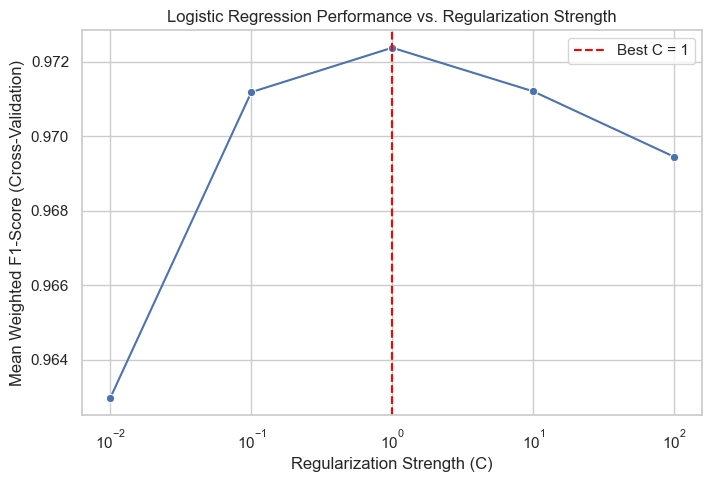

In [47]:
# Create the pipeline
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression())])

# Define hyperparameter grid
param_grid_lr = {
    'classifier__C': [0.01, 0.1, 1, 10, 100] # Regularization strength (low values -> high regularization, forces model to be more simple -> prevents overfitting. 
     #High values -> low regularization, allows model to fit training data better but may overfit)
}

# Use GridSearchCV to find the best value of C for regularization strength using weighted f1-score for each C as the evaluation metric
grid_search_lr = GridSearchCV(lr_pipeline, param_grid_lr, cv=5, scoring='f1_weighted', n_jobs=-1) # cv=5 means 5-fold cross-validation. The data is split into 5 parts, and the model is trained on 4 parts and validated on the 5th part, repeated 5 times.
grid_search_lr.fit(X_train, y_train)

print(f"Best hyperparameters for Logistic Regression: {grid_search_lr.best_params_}")
print(f"Best F1-score on CV: {grid_search_lr.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred_lr = grid_search_lr.predict(X_test)
print("\n--- Logistic Regression Evaluation ---")
print(classification_report(y_test, y_pred_lr))



###### CHECK FOR OVERFITTING
#    This is the average performance across the training data folds.
training_score_lr = grid_search_lr.best_score_

#  Calculate the same score on the unseen test data
testing_score_lr = f1_score(y_test, y_pred_lr, average='weighted')

#  Compare the two scores
print("\n--- Overfitting Check for Logistic Regression ---")
print(f"Cross-Validation F1-Score (Training Performance): {training_score_lr:.4f}")
print(f"Test Set F1-Score (Testing Performance):         {testing_score_lr:.4f}")



##### REGULARIZATION HYPERPARAMETER PLOT
# Extract results from the grid search
results_lr = pd.DataFrame(grid_search_lr.cv_results_)
c_values = results_lr['param_classifier__C'].astype(float)
scores = results_lr['mean_test_score']

# Plot the results
plt.figure(figsize=(8, 5))
sns.lineplot(x=c_values, y=scores, marker='o')
plt.xscale('log') # Use a log scale for C as it spans several orders of magnitude
plt.xlabel("Regularization Strength (C)")
plt.ylabel("Mean Weighted F1-Score (Cross-Validation)")
plt.title("Logistic Regression Performance vs. Regularization Strength")
plt.grid(True)

# Add a vertical line at the best parameter value
best_c = grid_search_lr.best_params_['classifier__C']
plt.axvline(x=best_c, color='red', linestyle='--', label=f'Best C = {best_c}')
plt.legend()
plt.show()


### Model 2: Random Forest Classifier

Best hyperparameters for Random Forest: {'classifier__max_depth': 10, 'classifier__n_estimators': 200}
Best F1-score on CV: 0.9770

--- Random Forest Evaluation ---
              precision    recall  f1-score   support

   Education       0.97      0.96      0.96       207
        Work       0.98      0.99      0.99       524

    accuracy                           0.98       731
   macro avg       0.98      0.97      0.97       731
weighted avg       0.98      0.98      0.98       731


--- Overfitting Check for Random Forest ---
Cross-Validation F1-Score (Training Performance): 0.9770
Test Set F1-Score (Testing Performance):         0.9795


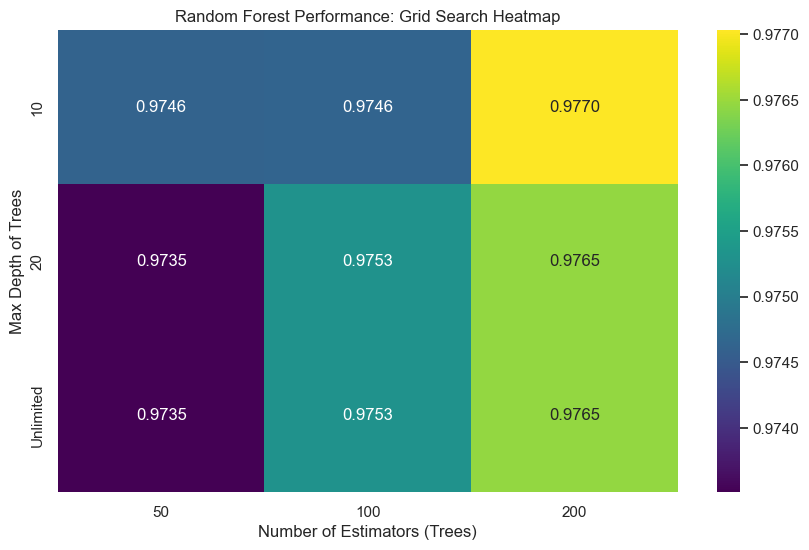

In [48]:
# Create the pipeline
rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(random_state=42))])

# Define hyperparameter grid
param_grid_rf = {
    'classifier__n_estimators': [50, 100, 200], # Number of trees
    'classifier__max_depth': [10, 20, None] # Max depth of trees
}

# Use GridSearchCV to find the best hyperparameters
grid_search_rf = GridSearchCV(rf_pipeline, param_grid_rf, cv=5, scoring='f1_weighted', n_jobs=-1)
grid_search_rf.fit(X_train, y_train)

print(f"Best hyperparameters for Random Forest: {grid_search_rf.best_params_}")
print(f"Best F1-score on CV: {grid_search_rf.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred_rf = grid_search_rf.predict(X_test)
print("\n--- Random Forest Evaluation ---")
print(classification_report(y_test, y_pred_rf))



###### CHECK FOR OVERFITTING
#    This is the average performance across the training data folds.
training_score_rf = grid_search_rf.best_score_

#  Calculate the same score on the unseen test data
testing_score_rf = f1_score(y_test, y_pred_rf, average='weighted')

#  Compare the two scores
print("\n--- Overfitting Check for Random Forest ---")
print(f"Cross-Validation F1-Score (Training Performance): {training_score_rf:.4f}")
print(f"Test Set F1-Score (Testing Performance):         {testing_score_rf:.4f}")



##### HYPERPARAMETER PLOT
# Extract results from the grid search object
results_rf = pd.DataFrame(grid_search_rf.cv_results_)
#  'max_depth' parameter might have 'None', use fillna to replace None with a string 'Unlimited'.
results_rf['param_classifier__max_depth'] = results_rf['param_classifier__max_depth'].fillna('Unlimited').astype(str)
#  Create a pivot table (a matrix) suitable for the heatmap
#    Rows: max_depth, Columns: n_estimators, Values: mean_test_score
pivot_table = results_rf.pivot_table(
    values='mean_test_score', 
    index='param_classifier__max_depth', 
    columns='param_classifier__n_estimators'
)
#  Plot the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, fmt=".4f", cmap="viridis")
plt.title("Random Forest Performance: Grid Search Heatmap")
plt.xlabel("Number of Estimators (Trees)")
plt.ylabel("Max Depth of Trees")
plt.show()



### 5. Confusion Matrix


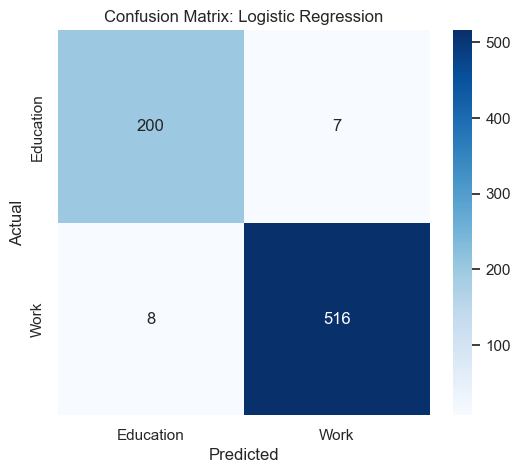

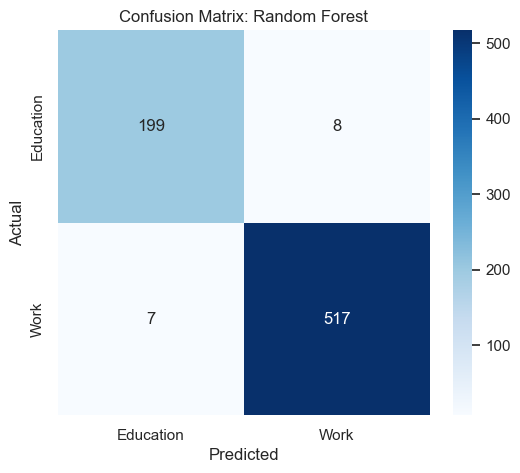

In [49]:
def plot_confusion_matrix(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Education', 'Work'], yticklabels=['Education', 'Work'])
    plt.title(f'Confusion Matrix: {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.show()

plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')